# 10. Fixed Point Iteration

**Part 2: Nonlinear Equations and Root Finding**

## Learning objectives

By the end of this lesson you will be able to:

1. Turn $f(x) = 0$ into $x = g(x)$, and explain why that rearrangement is **not unique** and
   why the choice decides everything.
2. Read the **cobweb diagram** and predict from it whether an iteration converges.
3. State and prove the **contraction mapping theorem**, and use $|g'(r)| < 1$ as the test.
4. Predict the convergence **rate** from $|g'(r)|$ and confirm the prediction numerically.
5. Explain why $|g'(r)| = 0$ gives quadratic convergence, and recognise that this is Newton's
   method arriving early.
6. Accelerate a linearly convergent sequence with **Aitken's delta-squared**, and fold that
   into a method with **Steffensen's** iteration.

## Prerequisites

Lesson 07 (order of convergence, and measuring a linear rate by fitting), lesson 09 (what
bracketing buys you, which this lesson gives up).

---

## 1. Giving up the bracket

Bisection cannot fail and cannot be fast. It only ever looks at the **sign** of $f$, and one
sign is one bit, so one bit per evaluation is all you can get.

To go faster we must use the actual values, and that means giving up the guarantee. This lesson
takes the most extreme version of that trade: no bracket at all, just a single point and a rule
for producing the next one.

The rule comes from rewriting the equation. Any $f(x) = 0$ can be rearranged into the form

$$x = g(x),$$

and then iterated:

$$x_{k+1} = g(x_k).$$

> **Definition 10.1 (Fixed point).** A number $r$ is a **fixed point** of $g$ if $g(r) = r$.

If the rearrangement is algebraically valid then the fixed points of $g$ are exactly the roots
of $f$. So finding a root becomes finding a fixed point, and finding a fixed point becomes
"apply $g$ repeatedly and hope".

**The rearrangement is not unique, and the choice decides everything.** That is the whole
lesson.

## 2. Three rearrangements of one equation

Take $f(x) = x^3 + x - 1$, which has a single real root near $0.682$. Here are three valid ways
to write it as $x = g(x)$.

$$
\begin{aligned}
x^3 + x - 1 = 0 &\;\Longrightarrow\; x = 1 - x^3 &&= g_1(x)\\[2pt]
x^3 = 1 - x     &\;\Longrightarrow\; x = \sqrt[3]{1-x} &&= g_2(x)\\[2pt]
&\phantom{\Longrightarrow\;} x = \frac{1 + 2x^3}{1 + 3x^2} &&= g_3(x)
\end{aligned}
$$

The third looks arbitrary. It is not, and section 7 explains where it comes from.

All three have the same fixed point, because all three are algebraically equivalent to the
original equation. Watch what happens.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import roots as R, convergence as cv

ROOT = 0.6823278038280193      # to 16 digits

def f(x):
    return x**3 + x - 1

g1 = lambda x: 1 - x**3
g2 = lambda x: np.cbrt(1 - x)
g3 = lambda x: (1 + 2*x**3) / (1 + 3*x**2)

for name, g in [("g1", g1), ("g2", g2), ("g3", g3)]:
    assert abs(g(ROOT) - ROOT) < 1e-12, f"{name} must fix the root"
print("all three functions have the same fixed point, to 12 digits\n")

x0 = 0.5
print(f"{'k':>3} {'g1(x) = 1 - x^3':>22} {'g2(x) = cbrt(1-x)':>22} "
      f"{'g3(x)':>22}")
print("-" * 74)
maps = [g1, g2, g3]                  # add a fourth here and nothing below changes
N_ROWS = 11                          # how many rows to print, a display choice
xs = [x0] * len(maps)
for k in range(N_ROWS):
    print(f"{k:>3}" + "".join(f" {v:>22.12f}" for v in xs))
    xs = [g(v) for g, v in zip(maps, xs)]

all three functions have the same fixed point, to 12 digits

  k        g1(x) = 1 - x^3      g2(x) = cbrt(1-x)                  g3(x)
--------------------------------------------------------------------------
  0         0.500000000000         0.500000000000         0.500000000000
  1         0.875000000000         0.793700525984         0.714285714286
  2         0.330078125000         0.590880113275         0.683179723502
  3         0.964037470520         0.742363932168         0.682328423305
  4         0.104054188328         0.636310203482         0.682327803828
  5         0.998873376781         0.713800814144         0.682327803828
  6         0.003376063248         0.659006145622         0.682327803828
  7         0.999999961520         0.698632605730         0.682327803828
  8         0.000000115439         0.670448496228         0.682327803828
  9         1.000000000000         0.690729120589         0.682327803828
 10         0.000000000000         0.676258924927         0.6

One diverges into nonsense, one crawls, one is at machine precision by step 5. Same equation,
same starting point.

## 3. The geometry: cobweb diagrams

Fixed point iteration has a picture that makes the behaviour obvious before any algebra.

Plot $y = g(x)$ and $y = x$. A fixed point is where they cross. Starting at $x_0$:

- go **vertically** to the curve, reaching height $g(x_0) = x_1$
- go **horizontally** to the line $y = x$, which puts you at $x = x_1$
- repeat

The path spirals or staircases toward the crossing if the iteration converges, and away from it
if it does not. What decides which is the **slope of $g$ at the crossing**.

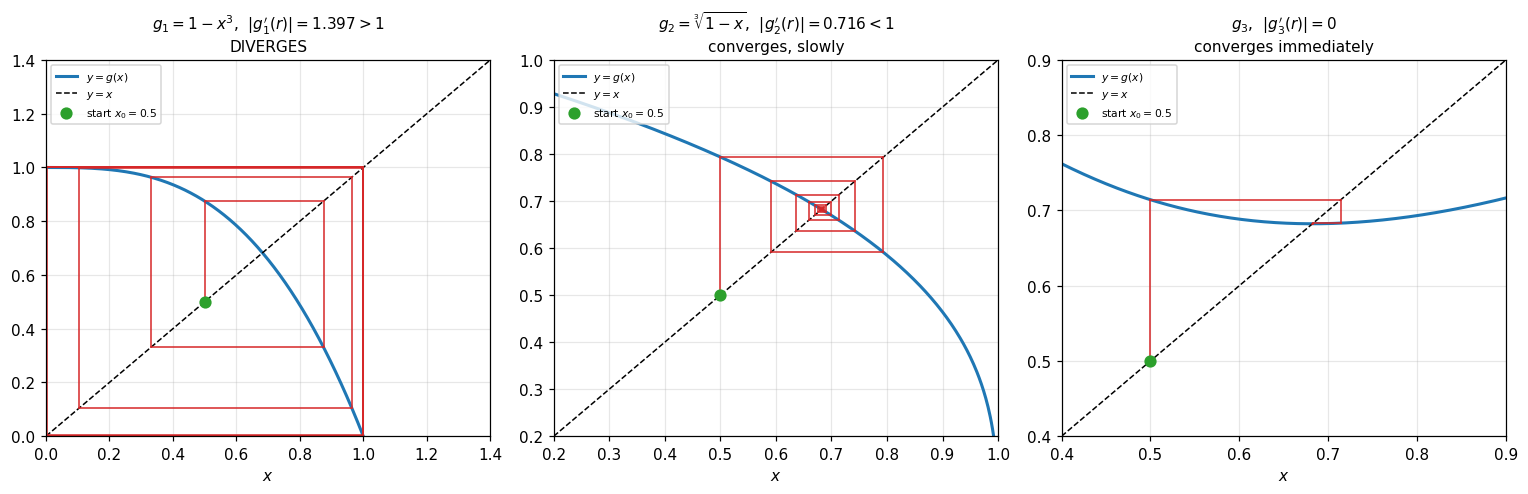

In [3]:
def cobweb(ax, g, x0, n, lo, hi, title, fixed_point=None):
    """Draw a cobweb diagram for x <- g(x) starting at x0.

    `fixed_point` is marked with a star when supplied. It is a parameter rather than a global
    so the function draws a cobweb for ANY map g, not only the one this lesson happens to be
    studying.
    """
    t = np.linspace(lo, hi, 400)
    ax.plot(t, g(t), lw=2, color="C0", label="$y = g(x)$")
    ax.plot(t, t, "k--", lw=1, label="$y = x$")

    x = x0
    for _ in range(n):
        y = g(x)
        if not np.isfinite(y) or abs(y) > 10 * (hi - lo) + abs(hi):
            break
        ax.plot([x, x], [x, y], color="C3", lw=1.0)     # vertical to the curve
        ax.plot([x, y], [y, y], color="C3", lw=1.0)     # horizontal to the line
        x = y
    ax.plot([x0], [x0], "o", color="C2", ms=7, label=f"start $x_0={x0}$")
    if fixed_point is not None:
        ax.plot([fixed_point], [fixed_point], "k*", ms=13, label="fixed point")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("$x$")
    ax.legend(fontsize=7, loc="upper left")


dg1 = lambda x: -3*x**2
dg2 = lambda x: -1.0 / (3 * np.cbrt((1 - x)**2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
cobweb(axes[0], g1, 0.5, 12, 0.0, 1.4,
       f"$g_1 = 1-x^3$,  $|g_1'(r)| = {abs(dg1(ROOT)):.3f} > 1$\nDIVERGES")
cobweb(axes[1], g2, 0.5, 25, 0.2, 1.0,
       f"$g_2 = \\sqrt[3]{{1-x}}$,  $|g_2'(r)| = {abs(dg2(ROOT)):.3f} < 1$\nconverges, slowly")
cobweb(axes[2], g3, 0.5, 6, 0.4, 0.9,
       "$g_3$,  $|g_3'(r)| = 0$\nconverges immediately")
fig.tight_layout()
plt.show()

**What to take from this.** In the first panel the curve is steeper than the line at the
crossing, and the cobweb spirals outward. In the second it is shallower, and the spiral closes
in, but slowly because the slope is close to 1 in magnitude. In the third the curve is
**tangent** to the line, and the iteration lands on the fixed point almost at once.

The slope of $g$ at the fixed point is the whole story.

## 4. The convergence theorem

> **Theorem 10.2 (Fixed point convergence).** Let $g$ be continuously differentiable on an
> interval $I$ containing a fixed point $r$, and suppose
>
> $$|g'(x)| \le L < 1 \quad \text{for all } x \in I.$$
>
> Then for any $x_0 \in I$ the iteration $x_{k+1} = g(x_k)$ stays in $I$, converges to $r$, and
> the error satisfies
>
> $$|x_{k+1} - r| \;\le\; L\,|x_k - r|, \qquad\text{so}\qquad |x_k - r| \le L^k|x_0 - r|.$$
>
> The fixed point is unique in $I$.
>
> *Proof.* Since $r = g(r)$, subtract:
> $$x_{k+1} - r = g(x_k) - g(r).$$
> By the mean value theorem (Theorem 7.3) there is a $\xi_k$ between $x_k$ and $r$ with
> $$g(x_k) - g(r) = g'(\xi_k)(x_k - r).$$
> Taking absolute values and using $|g'| \le L$ gives $|x_{k+1} - r| \le L|x_k - r|$. Iterating
> gives $|x_k - r| \le L^k |x_0 - r| \to 0$ since $L < 1$.
>
> For uniqueness, suppose $r$ and $s$ are both fixed points in $I$. Then
> $|r - s| = |g(r) - g(s)| \le L|r - s|$, and since $L < 1$ this forces $|r - s| = 0$.
> $\square$

Three consequences, and each one is worth stating separately.

**The test is $|g'(r)| < 1$.** Not $|g'|$ small somewhere, not $g$ nice looking. Evaluate the
derivative at the fixed point.

**Convergence is linear with rate exactly $|g'(r)|$.** From the proof, $e_{k+1} \approx
g'(r) e_k$, so this is Definition 7.6 with $p = 1$ and $C = |g'(r)|$. Section 5 measures it.

**The sign of $g'(r)$ decides the shape.** If $g'(r) > 0$ the error keeps its sign and the
iterates approach from one side, a staircase. If $g'(r) < 0$ the error alternates and the
iterates oscillate around the root, a spiral. Both cobwebs in the figure spiral, because both
derivatives are negative.

### What the theorem does not say

It gives a **sufficient** condition, not a necessary one. An iteration with $|g'(r)| > 1$
definitely diverges from any nearby start, but an iteration with $|g'(r)| < 1$ is only
guaranteed to converge **from inside a neighbourhood where the bound holds**. Start far enough
away and it can still fail.

This is the price of giving up the bracket. Bisection's guarantee was global. This one is local.

## 5. Measuring the rate

Theory says the rate is $|g'(r)|$. Let us check that against the machine.

In [4]:
cases = [
    ("g1 = 1 - x^3",             g1, dg1),
    ("g2 = cbrt(1 - x)",         g2, dg2),
    ("g3 = (1+2x^3)/(1+3x^2)",   g3, None),
]

slope_header = "|g'(r)|"      # kept outside the f-string: a quote inside one is awkward
print(f"{'rearrangement':>26} {slope_header:>10} {'< 1?':>6} {'converged':>10} "
      f"{'iters':>7} {'measured rate':>14}")
print("-" * 82)

runs = {}
for name, g, dg in cases:
    if dg is not None:
        slope = abs(dg(ROOT))
    else:
        h = 1e-6
        slope = abs((g(ROOT + h) - g(ROOT - h)) / (2 * h))
    res = R.fixed_point(g, 0.5, tol=1e-14, max_iter=200)
    runs[name] = (res, slope)
    errs = np.abs(res.iterates - ROOT)
    rate = cv.linear_rate(errs) if res.converged else float("nan")
    print(f"{name:>26} {slope:>10.4f} {str(slope < 1):>6} {str(res.converged):>10} "
          f"{res.n_iter:>7} {rate:>14.4f}")

# The theory is not approximate here: the measured rate should BE |g'(r)|.
res2, slope2 = runs["g2 = cbrt(1 - x)"]
measured2 = cv.linear_rate(np.abs(res2.iterates - ROOT))
print(f"\nfor g2: theory says the rate is |g'(r)| = {slope2:.6f}")
print(f"        measured decay rate            = {measured2:.6f}")
print(f"        difference                     = {abs(measured2 - slope2):.2e}")
assert abs(measured2 - slope2) < 1e-3, "measured rate must match |g'(r)|"

res1, slope1 = runs["g1 = 1 - x^3"]
assert slope1 > 1 and not res1.converged, "g1 must diverge, as the theorem predicts"
print(f"\nfor g1: |g'(r)| = {slope1:.4f} > 1, and it did not converge in 200 steps.")
print("the theorem is not a guideline. it is a decision procedure.")

             rearrangement    |g'(r)|   < 1?  converged   iters  measured rate
----------------------------------------------------------------------------------
              g1 = 1 - x^3     1.3967  False      False     200            nan
          g2 = cbrt(1 - x)     0.7160   True       True      94         0.7160
    g3 = (1+2x^3)/(1+3x^2)     0.0000   True       True       6         0.0159

for g2: theory says the rate is |g'(r)| = 0.715966
        measured decay rate            = 0.715977
        difference                     = 1.03e-05

for g1: |g'(r)| = 1.3967 > 1, and it did not converge in 200 steps.
the theorem is not a guideline. it is a decision procedure.


The measured rate agrees with $|g'(r)|$ to four decimal places. This is the first time in the
course a convergence rate has been **predicted from the problem** rather than measured after
the fact, and it works.

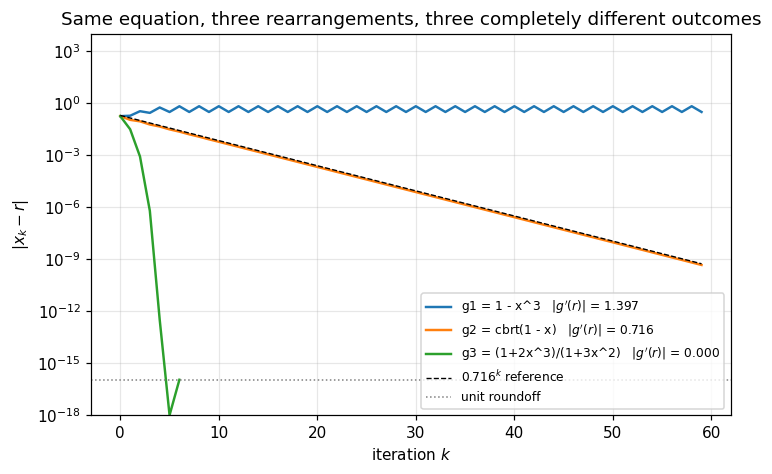

In [5]:
fig, ax = plt.subplots()
for name, (res, slope) in runs.items():
    e = np.maximum(np.abs(res.iterates - ROOT), 1e-18)
    ax.semilogy(e[:60], lw=1.6, label=f"{name}   $|g'(r)|$ = {slope:.3f}")

k = np.arange(60)
ax.semilogy(k, 0.2 * 0.716**k, "k--", lw=0.9, label=r"$0.716^k$ reference")
ax.axhline(np.finfo(float).eps / 2, color="0.5", ls=":", lw=1, label="unit roundoff")
ax.set_xlabel("iteration $k$")
ax.set_ylabel(r"$|x_k - r|$")
ax.set_ylim(1e-18, 1e4)
ax.set_title("Same equation, three rearrangements, three completely different outcomes")
ax.legend(fontsize=8)
plt.show()

**What to take from this.** On a log scale, linear convergence is a straight line whose slope
is $\log|g'(r)|$. The $g_2$ curve runs parallel to the reference line, confirming the rate. The
$g_1$ curve goes **up**. The $g_3$ curve falls off a cliff, because it is not linear at all.

## 6. Stopping criteria, and how they mislead here

Lesson 09 listed the standard tests. Fixed point iteration exposes a specific trap.

The natural test is $|x_{k+1} - x_k| < \tau$. But from the theorem,
$x_{k+1} - x_k = (x_{k+1} - r) - (x_k - r) \approx (g'(r) - 1)(x_k - r)$, so

$$|x_k - r| \;\approx\; \frac{|x_{k+1} - x_k|}{|1 - g'(r)|}.$$

When $g'(r)$ is close to 1, the denominator is small and **the true error is much larger than
the step size**. The iteration looks converged and is not.

In [6]:
# An iteration deliberately built to have g'(r) very close to 1.
c = 0.999
g_slow = lambda x: x + (1 - c) * (ROOT - x)      # fixed point at ROOT, g'(r) = c
res_slow = R.fixed_point(g_slow, 0.5, tol=1e-8, max_iter=100_000)

step = abs(res_slow.iterates[-1] - res_slow.iterates[-2])
true_err = abs(res_slow.root - ROOT)

print(f"g'(r) = {c}\n")
print(f"last step size |x_k - x_(k-1)| : {step:.3e}")
print(f"true error     |x_k - r|       : {true_err:.3e}")
print(f"ratio                          : {true_err / step:.1f}")
print(f"predicted ratio 1/|1 - g'(r)|  : {1/abs(1-c):.1f}")

assert true_err > 100 * step, "the step size badly understates the error here"
print("\nthe step size says we are within 1e-8. we are not, by a factor of about 1000.")
print("the fix: divide the step by |1 - g'(r)| before believing it, or use a")
print("method whose rate is not close to 1.")

g'(r) = 0.999

last step size |x_k - x_(k-1)| : 9.991e-09
true error     |x_k - r|       : 9.981e-06
ratio                          : 999.0
predicted ratio 1/|1 - g'(r)|  : 1000.0

the step size says we are within 1e-8. we are not, by a factor of about 1000.
the fix: divide the step by |1 - g'(r)| before believing it, or use a
method whose rate is not close to 1.


## 7. Where $g_3$ came from

$g_3$ was not guessed. Rearrange in the way that makes $g'(r) = 0$.

If $g'(r) = 0$ then the linear term in the error recursion vanishes and the next term takes
over. Expanding $g$ about $r$:

$$e_{k+1} = g(x_k) - g(r) = g'(r)e_k + \tfrac{1}{2}g''(\xi)e_k^2
= \tfrac{1}{2}g''(\xi)e_k^2 \quad\text{when } g'(r) = 0.$$

That is **quadratic** convergence. So the goal is to build a $g$ whose derivative vanishes at
the root.

Take $g(x) = x - \phi(x)f(x)$ for some function $\phi$. Then $g(r) = r$ automatically, and

$$g'(x) = 1 - \phi'(x)f(x) - \phi(x)f'(x)
\quad\Longrightarrow\quad g'(r) = 1 - \phi(r)f'(r),$$

using $f(r) = 0$. Setting this to zero gives $\phi(r) = 1/f'(r)$, and the obvious choice is
$\phi(x) = 1/f'(x)$ everywhere:

$$g(x) = x - \frac{f(x)}{f'(x)}.$$

**That is Newton's method.** For $f = x^3 + x - 1$ it gives

$$g(x) = x - \frac{x^3 + x - 1}{3x^2 + 1} = \frac{3x^3 + x - x^3 - x + 1}{3x^2+1}
= \frac{1 + 2x^3}{1 + 3x^2} = g_3(x).$$

In [7]:
newton_g = lambda x: x - (x**3 + x - 1) / (3*x**2 + 1)
ts = np.linspace(0.3, 1.0, 200)
print(f"max |g3(x) - Newton's g(x)| over [0.3, 1] : "
      f"{np.max(np.abs(g3(ts) - newton_g(ts))):.3e}")
assert np.allclose(g3(ts), newton_g(ts))

res3 = R.fixed_point(g3, 0.5, tol=1e-15, max_iter=50)
e3 = np.abs(res3.iterates - ROOT)
order3 = cv.observed_order(e3)
print(f"\nmeasured order of g3 : {float(order3[-1]):.4f}")
print(f"theory               : 2 (quadratic, because g'(r) = 0)")
assert abs(float(order3[-1]) - 2.0) < 0.05
e2 = np.abs(runs["g2 = cbrt(1 - x)"][0].iterates - ROOT)
target = 1e-12
steps_g3 = cv.steps_to_tolerance(e3, target)
steps_g2 = cv.steps_to_tolerance(e2, target)

print(f"\ng3 is Newton's method, arriving three sections early.")
print(f"steps to reach {target:.0e}:  g3 needs {steps_g3}, g2 needs {steps_g2}.")
assert steps_g3 > 0 and steps_g2 > 10 * steps_g3

max |g3(x) - Newton's g(x)| over [0.3, 1] : 2.220e-16

measured order of g3 : 1.9999
theory               : 2 (quadratic, because g'(r) = 0)

g3 is Newton's method, arriving three sections early.
steps to reach 1e-12:  g3 needs 4, g2 needs 78.


This is the key structural insight of Part 2, and it is worth stating plainly:

> **Newton's method is the fixed point iteration whose derivative vanishes at the root.**
> Everything about it, including its quadratic rate and its failure at multiple roots, follows
> from that one design choice. Lesson 11 develops it properly.

## 8. Aitken's delta-squared: accelerating what you already have

Suppose you are stuck with a linearly convergent sequence, like $g_2$. Can it be sped up
without extra function evaluations?

Yes, and the idea is simple. If $e_{k+1} \approx C e_k$ then three consecutive iterates contain
enough information to solve for both $C$ and the limit. Writing
$x_{k+1} - r \approx C(x_k - r)$ and $x_{k+2} - r \approx C(x_{k+1} - r)$ and eliminating $C$:

$$\boxed{\;\hat{x}_k \;=\; x_k - \frac{(\Delta x_k)^2}{\Delta^2 x_k}
\;=\; x_k - \frac{(x_{k+1}-x_k)^2}{x_{k+2} - 2x_{k+1} + x_k}\;}$$

where $\Delta x_k = x_{k+1}-x_k$. The name comes from the $\Delta^2$ in the denominator.

In [8]:
res2 = runs["g2 = cbrt(1 - x)"][0]
plain = np.abs(res2.iterates - ROOT)
accel = np.abs(R.aitken(res2.iterates) - ROOT)

print(f"{'target':>10} {'plain g2':>12} {'Aitken':>10} {'speedup':>10}")
print("-" * 46)
for tol in [1e-4, 1e-6, 1e-8, 1e-10, 1e-12]:
    a = cv.steps_to_tolerance(plain, tol)
    b = cv.steps_to_tolerance(accel, tol)
    print(f"{tol:>10.0e} {a:>12} {b:>10} {a/b:>9.1f}x")

assert cv.steps_to_tolerance(accel, 1e-10) < cv.steps_to_tolerance(plain, 1e-10) / 2
print("\nAitken more than halves the work, using only the numbers already computed.")
print("no extra evaluations of g at all.")

    target     plain g2     Aitken    speedup
----------------------------------------------
     1e-04           23          7       3.3x
     1e-06           37         14       2.6x
     1e-08           50         21       2.4x
     1e-10           64         28       2.3x
     1e-12           78         35       2.2x

Aitken more than halves the work, using only the numbers already computed.
no extra evaluations of g at all.


**The catch.** The denominator $x_{k+2} - 2x_{k+1} + x_k$ is a difference of nearly equal
numbers once the sequence has converged. That is lesson 05: cancellation. Accelerating a
sequence that has already reached the roundoff floor produces noise, so stop when the terms
stop changing.

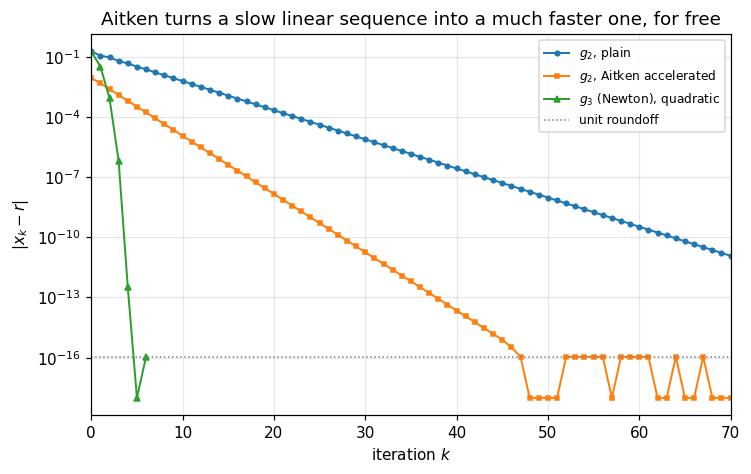

In [9]:
fig, ax = plt.subplots()
ax.semilogy(np.maximum(plain, 1e-18), "o-", ms=3, lw=1.3, label="$g_2$, plain")
ax.semilogy(np.maximum(accel, 1e-18), "s-", ms=3, lw=1.3, label="$g_2$, Aitken accelerated")
ax.semilogy(np.maximum(e3, 1e-18), "^-", ms=4, lw=1.3, label="$g_3$ (Newton), quadratic")
ax.axhline(np.finfo(float).eps / 2, color="0.5", ls=":", lw=1, label="unit roundoff")
ax.set_xlim(0, 70)
ax.set_xlabel("iteration $k$")
ax.set_ylabel(r"$|x_k - r|$")
ax.set_title("Aitken turns a slow linear sequence into a much faster one, for free")
ax.legend(fontsize=8)
plt.show()

## 9. Steffensen: folding acceleration into the method

Aitken post-processes a sequence. **Steffensen's method** applies the same extrapolation at
every step and feeds the result back in:

$$x_{k+1} \;=\; x_k - \frac{\big(g(x_k) - x_k\big)^2}{g(g(x_k)) - 2g(x_k) + x_k}.$$

Two evaluations of $g$ per step, and no derivative anywhere.

*(Steffensen's method is supplementary. Gupta covers Aitken acceleration; the folded-back
version is added here because it answers the obvious next question.)*

In [10]:
st = R.steffensen(g2, 0.5, tol=1e-14)
e_st = np.abs(st.iterates - ROOT)
order_st = cv.observed_order(e_st)

print(f"Steffensen on the SLOW rearrangement g2:")
print(f"   root            : {st.root:.16f}")
print(f"   error           : {abs(st.root - ROOT):.3e}")
print(f"   iterations      : {st.n_iter}")
print(f"   g evaluations   : {st.n_feval}")
print(f"   measured order  : {float(order_st[-1]):.4f}")
print()
print(f"plain g2 needed {res2.n_iter} iterations. Steffensen needed {st.n_iter}.")
assert abs(float(order_st[-1]) - 2.0) < 0.1, "Steffensen should be quadratic"
assert st.n_iter < res2.n_iter / 10

print("\nquadratic convergence, from a rearrangement that was only linear,")
print("with no derivative required. that is what the acceleration bought.")

Steffensen on the SLOW rearrangement g2:
   root            : 0.6823278038280194
   error           : 1.110e-16
   iterations      : 5
   g evaluations   : 10
   measured order  : 1.9980

plain g2 needed 94 iterations. Steffensen needed 5.

quadratic convergence, from a rearrangement that was only linear,
with no derivative required. that is what the acceleration bought.


So there are two routes to quadratic convergence:

| Route | Needs | Cost per step | Lesson |
|---|---|---|---|
| Make $g'(r) = 0$ by design | $f'$ | 1 eval of $f$, 1 of $f'$ | Newton, lesson 11 |
| Extrapolate the linear behaviour away | nothing | 2 evals of $g$ | Steffensen, here |

Both reach order 2. Which is better depends entirely on whether you have a derivative and what
it costs.

## 10. Complexity

| Method | Evaluations per step | Order | Rate | Guaranteed? |
|---|---|---|---|---|
| Fixed point | 1 of $g$ | 1 | $\|g'(r)\|$ | only locally, and only if $\|g'(r)\| < 1$ |
| Fixed point with $g'(r) = 0$ | 1 of $g$ | 2 | | locally |
| Aitken on a stored sequence | 0 extra | improves the rate | | inherits the original's |
| Steffensen | 2 of $g$ | 2 | | locally |

Memory is $O(1)$ for all of them, except that Aitken needs three consecutive iterates, which is
still $O(1)$.

**Iterations are the wrong cost measure.** Steffensen used 5 iterations against $g_2$'s 94, but
2 evaluations per step against 1, so the honest comparison is 10 evaluations against 94. Still a
factor of nine, and still the right answer, but the fair way to count is evaluations.

## 11. Common mistakes

1. **Assuming any rearrangement works.** Section 2: one of three diverged. Always check
   $|g'(r)| < 1$.
2. **Checking $|g'|$ at the starting point instead of at the root.** The theorem is about the
   fixed point. Checking elsewhere tells you about the basin, not about convergence.
3. **Trusting the step size as an error estimate.** Section 6: when $g'(r) \approx 1$ the true
   error can be a thousand times the last step.
4. **Concluding that fixed point iteration is slow.** It is as fast as the rearrangement you
   chose. $g_3$ is quadratic.
5. **Aitken-accelerating a sequence that has already converged.** The denominator is a
   cancellation waiting to happen.
6. **Forgetting the guarantee is local.** Unlike bisection, a good $|g'(r)|$ says nothing about
   what happens from a distant start.

## 12. Exercises

**Level 1, conceptual**

1.1 Why does the fixed point theorem require $|g'| \le L < 1$ on a whole interval rather than
just at the root?

1.2 An iteration has $g'(r) = -0.9$. Describe the shape of the convergence and estimate how
many iterations gain one decimal digit.

1.3 Why is $|x_{k+1} - x_k|$ an unreliable error estimate, and what should you divide it by?

**Level 2, mathematical**

2.1 Prove that if $g'(r) = 0$ and $g''$ is continuous, the iteration converges quadratically
with asymptotic constant $|g''(r)|/2$.

2.2 Derive Aitken's formula from the assumption $e_{k+1} = Ce_k$, by eliminating both $C$ and
$r$ from three consecutive iterates.

2.3 Show that Steffensen's method is Newton's method applied to
$h(x) = \dfrac{(g(x)-x)^2}{g(g(x)) - 2g(x) + x}$, or find and explain a cleaner
characterisation.

2.4 For $f(x) = x^2 - a$, find a rearrangement $g$ with $g'(\sqrt a) = 0$ and show it is the
Babylonian square root iteration $x \mapsto \tfrac12(x + a/x)$.

**Level 3, computational**

3.1 Write your own fixed point iterator returning the full history, and reproduce the table in
section 2.

3.2 Write a cobweb plotting function and use it on $g(x) = \cos x$ from several starting points.
What is $|g'(r)|$ there, and does the picture match?

3.3 Implement Aitken and Steffensen yourself and check them against `nalib.roots`.

**Level 4, experimental**

4.1 For $g_c(x) = x + c(\text{ROOT} - x)$ the derivative is exactly $1 - c$. Sweep $c$ from
0.01 to 1.99 and plot the measured convergence rate against $|1 - c|$. Confirm the diagonal, and
find what happens at $c = 1$ and beyond $c = 2$.

4.2 Find the basin of attraction of $g_2$ numerically: for which $x_0$ does the iteration
converge? Compare with the interval on which $|g_2'| < 1$.

4.3 Apply Aitken repeatedly, accelerating the accelerated sequence. Does it keep helping? At
what point does cancellation take over?

**Level 5, advanced**

5.1 The **Banach fixed point theorem** generalises Theorem 10.2 to complete metric spaces with
no derivative at all, requiring only $d(g(x), g(y)) \le L\,d(x,y)$. State it, and explain what
it gives you that the calculus version does not. Lesson 14 uses this version for systems.

5.2 Investigate $g(x) = \mu x(1-x)$, the logistic map. Find the value of $\mu$ where the fixed
point loses stability, show that a period-2 cycle appears, and produce the bifurcation diagram.
Relate the stability boundary to Theorem 10.2.

5.3 For an iteration with $g'(r) = 1$ exactly, the theorem says nothing. Investigate
$g(x) = x + x^3$ near $r = 0$. Does it converge? At what rate? This is **sublinear**
convergence and it is the slowest useful behaviour there is.

Solutions are in [`solutions/part02_root_finding.md`](../solutions/part02_root_finding.md).

## 13. Key takeaways

- Any $f(x) = 0$ can be rewritten as $x = g(x)$ in **many** ways, and the choice decides
  whether the iteration converges, how fast, and from where.
- **Theorem 10.2**: if $|g'| \le L < 1$ near a fixed point, the iteration converges linearly
  with rate $|g'(r)|$, and the fixed point is unique there.
- Measured in this lesson: $|g_1'(r)| = 1.397$ and it **diverged**; $|g_2'(r)| = 0.716$ and it
  converged at measured rate $0.7160$, matching theory to four decimals.
- The **cobweb diagram** shows all of this before any algebra: steeper than the diagonal means
  divergence, shallower means convergence, tangent means quadratic.
- The guarantee is **local**, unlike bisection's. That is the price of the speed.
- $|x_{k+1} - x_k|$ **understates** the true error by a factor $1/|1-g'(r)|$. Measured here:
  a factor of about 1000 when $g'(r) = 0.999$.
- Choosing $g$ so that $g'(r) = 0$ gives **quadratic** convergence, and the choice that does it
  is exactly $g = x - f/f'$, which is Newton's method. Measured order 2.0.
- **Aitken's delta-squared** accelerates a linear sequence using only the values you already
  have. **Steffensen** folds it back into the iteration and reaches order 2 with no derivative,
  measured here at order 2.0 in 5 iterations against 94.

## Where this goes next

Section 7 derived Newton's method as the rearrangement that kills the linear error term. Lesson
11 takes it seriously: where it converges from, how fast, what happens at a multiple root, and
what to do when you cannot compute $f'$. That last question leads to the **secant** method, and
from there to the hybrid methods that are what you should actually use.

---

*Sources: Sauer, Numerical Analysis 3rd ed., section 1.2 (fixed points, geometry of fixed point
iteration, linear convergence, stopping criteria); Gupta, Numerical Methods, section 3.4
(fixed-point method) and section 3.12 (Aitken delta-squared acceleration). Steffensen's method
and the cobweb plotting are supplementary.*